# CIFAR-10 RGB v2 — Final Testing

Load the saved RGB v2 CNN and SVM. This notebook uses only the official CIFAR-10 test split for inference and reporting; it does not fit or select models.


In [33]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 30092026

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf

# Hindari TensorFlow langsung mengalokasikan hampir seluruh VRAM.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print("GPU:", gpus)

tf.random.set_seed(SEED)

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Unseen CIFAR-10 Test Set

In [34]:
_, (X_test, y_test) = cifar10.load_data()

y_test = y_test.flatten()

labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

classes_name = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (10000, 32, 32, 3)
y_test: (10000,)


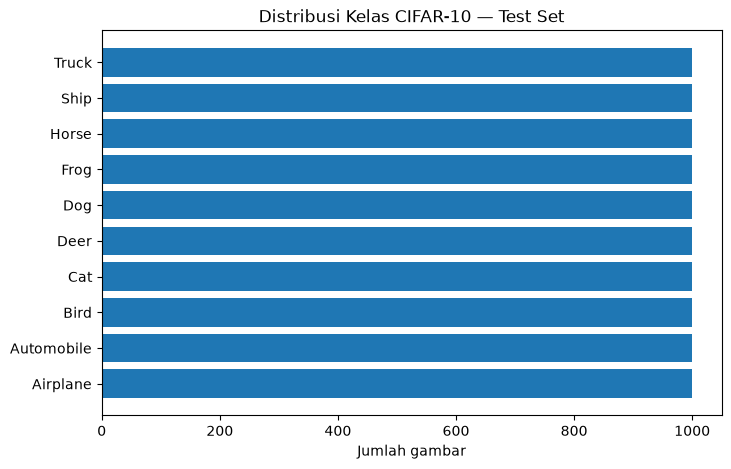

In [35]:
classes, counts = np.unique(
    y_test,
    return_counts=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    classes_name,
    counts
)
plt.title(
    "Distribusi Kelas CIFAR-10 — Test Set"
)
plt.xlabel("Jumlah gambar")
plt.show()

## 2. Preprocessing

Harus identik dengan preprocessing training.

In [36]:
X_test = X_test.astype(
    "float32"
) / 255.0

y_cat_test = to_categorical(
    y_test,
    10
)

print("X_test:", X_test.shape)
print("y_cat_test:", y_cat_test.shape)

X_test: (10000, 32, 32, 3)
y_cat_test: (10000, 10)


## 3. Load Custom CNN dan SVM

In [37]:
CNN_MODEL_PATH = "cifar10_custom_cnn_v2.keras"
SVM_MODEL_PATH = "cifar10_svm_v2.joblib"

if not os.path.exists(CNN_MODEL_PATH):
    raise FileNotFoundError(
        f"{CNN_MODEL_PATH} tidak ditemukan. "
        "Jalankan notebook training terlebih dahulu."
    )

if not os.path.exists(SVM_MODEL_PATH):
    raise FileNotFoundError(
        f"{SVM_MODEL_PATH} tidak ditemukan. "
        "Jalankan notebook training terlebih dahulu."
    )

# Bersihkan session TensorFlow lama agar penggunaan VRAM lebih aman.
tf.keras.backend.clear_session()

# CNN hanya digunakan untuk inference / feature extraction.
cnn_model = load_model(
    CNN_MODEL_PATH,
    compile=False
)

# SVM Pipeline berisi StandardScaler + trained RBF-SVM.
svm_model = joblib.load(
    SVM_MODEL_PATH
)

print("CNN berhasil dimuat dari:")
print(CNN_MODEL_PATH)

print("\nSVM berhasil dimuat dari:")
print(SVM_MODEL_PATH)

print("\nCNN summary:")
cnn_model.summary()

print("\nSVM pipeline:")
print(svm_model)

CNN berhasil dimuat dari:
cifar10_custom_cnn_v2.keras

SVM berhasil dimuat dari:
cifar10_svm_v2.joblib

CNN summary:


Model: "custom_cifar10_rgb_residual_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │      1,728 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 32, 32,    │     36,864 │ stem_relu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 32, 32,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 32, 32,    │     36,864 │ stage1_block1_ou… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 32, 32,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_add   │ (None, 32, 32,    │          0 │ stage1_block2_bn

 Total params: 11,447,754 (43.67 MB)

 Trainable params: 11,437,130 (43.63 MB)

 Non-trainable params: 10,624 (41.50 KB)


SVM pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=30, cache_size=2048))])


# 4. Feature Map Extraction pada Test Image

Sama seperti tahap feature-map extraction saat training, tetapi sekarang menggunakan gambar yang benar-benar unseen.

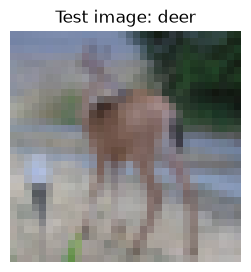

stem_relu: (1, 32, 32, 64)


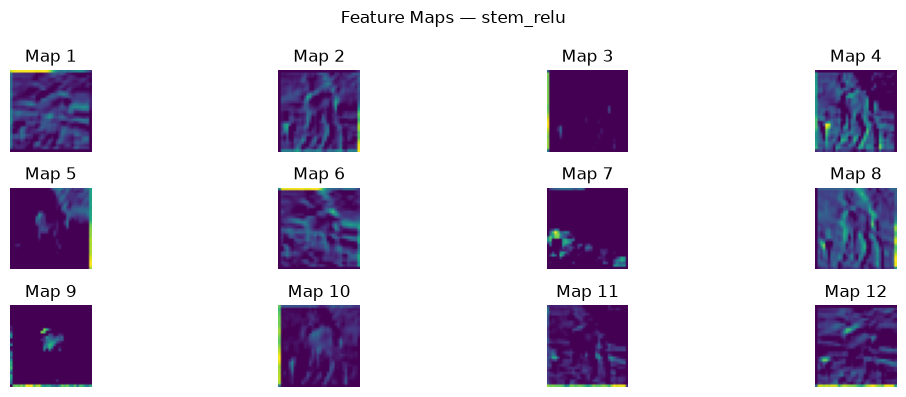

stage2_block2_out: (1, 16, 16, 128)


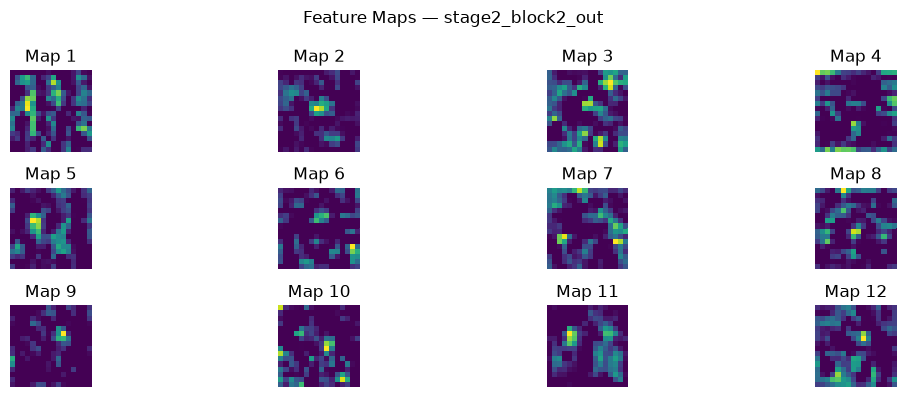

stage3_block2_out: (1, 8, 8, 256)


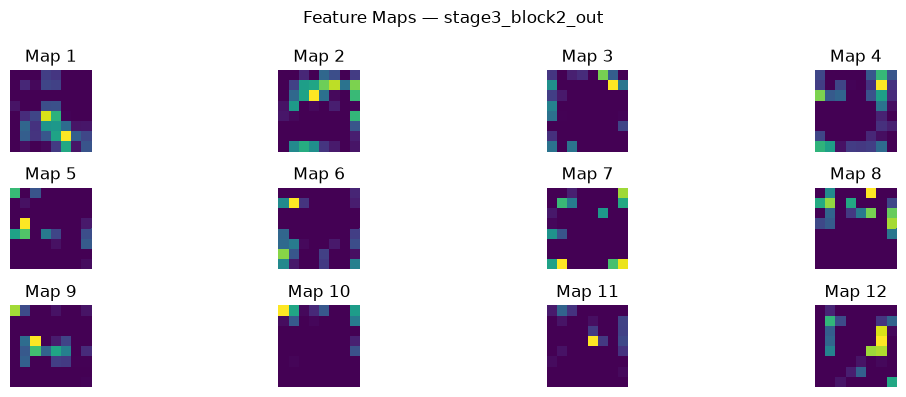

feature_map: (1, 4, 4, 512)


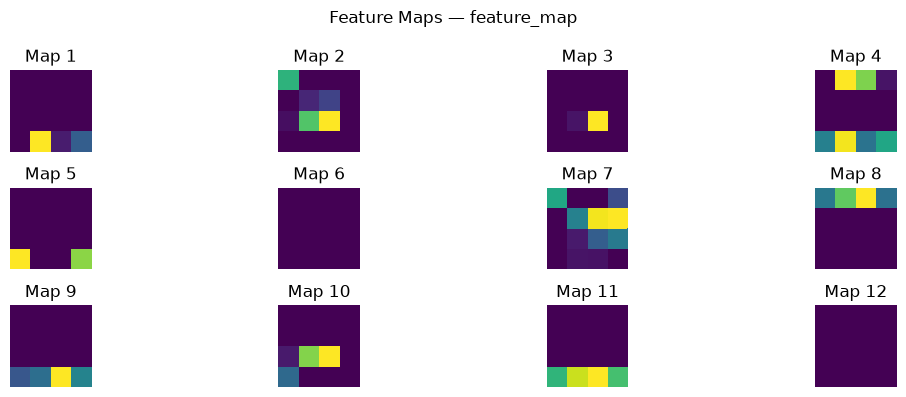

In [38]:
FEATURE_MAP_LAYERS = [
    "stem_relu",
    "stage2_block2_out",
    "stage3_block2_out",
    "feature_map"
]

feature_map_model = Model(
    inputs=cnn_model.input,
    outputs=[
        cnn_model.get_layer(name).output
        for name in FEATURE_MAP_LAYERS
    ],
    name="feature_map_extractor"
)

sample_index = 100
sample_image = X_test[
    sample_index:sample_index + 1
]

feature_maps = feature_map_model.predict(
    sample_image,
    verbose=0
)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0])
plt.title(
    f"Test image: "
    f"{labels[y_test[sample_index]]}"
)
plt.axis("off")
plt.show()

for layer_name, fmap in zip(
    FEATURE_MAP_LAYERS,
    feature_maps
):
    n_show = min(
        12,
        fmap.shape[-1]
    )

    print(
        f"{layer_name}: {fmap.shape}"
    )

    plt.figure(figsize=(12, 4))

    for i in range(n_show):
        plt.subplot(
            3,
            4,
            i + 1
        )
        plt.imshow(
            fmap[0, :, :, i],
            cmap="viridis"
        )
        plt.title(
            f"Map {i + 1}"
        )
        plt.axis("off")

    plt.suptitle(
        f"Feature Maps — {layer_name}"
    )
    plt.tight_layout()
    plt.show()

## 5. Baseline: Evaluasi CNN Softmax

Ini hanya pembanding.

Hasil utama tugas tetap **CNN feature extraction + SVM**.

In [39]:
cnn_probability = cnn_model.predict(
    X_test,
    batch_size=128,
    verbose=1
)

cnn_prediction = np.argmax(
    cnn_probability,
    axis=1
)

cnn_accuracy = accuracy_score(
    y_test,
    cnn_prediction
)

print(
    f"CNN test accuracy: "
    f"{cnn_accuracy * 100:.2f}%"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step
CNN test accuracy: 92.58%


# 6. Extract CNN Features untuk Seluruh Test Set

SVM menerima output layer `svm_features`, yaitu proyeksi Dense + BatchNormalization tanpa ReLU setelah Global Average Pooling.

In [40]:
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer(
        "svm_features"
    ).output,
    name="cnn_feature_extractor"
)

X_test_features = feature_extractor.predict(
    X_test,
    batch_size=128,
    verbose=1
)

print(
    "Original test shape:",
    X_test.shape
)

print(
    "Extracted feature shape:",
    X_test_features.shape
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step
Original test shape: (10000, 32, 32, 3)
Extracted feature shape: (10000, 512)


# 7. Klasifikasi SVM

In [41]:
svm_prediction = svm_model.predict(X_test_features)
svm_accuracy = accuracy_score(y_test, svm_prediction)
print("RGB CNN softmax test accuracy:", f"{cnn_accuracy:.4%}")
print("RGB CNN features + SVM test accuracy:", f"{svm_accuracy:.4%}")
print("Optional individual >95% milestone:", "PASS" if svm_accuracy > 0.95 else "NOT YET")

RGB CNN softmax test accuracy: 92.5800%
RGB CNN features + SVM test accuracy: 92.9700%
Optional individual >95% milestone: NOT YET


## 8. Classification Report SVM

In [42]:
print(
    classification_report(
        y_test,
        svm_prediction,
        target_names=labels,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.9474    0.9370    0.9422      1000
  automobile     0.9683    0.9780    0.9731      1000
        bird     0.8893    0.9160    0.9025      1000
         cat     0.8488    0.8420    0.8454      1000
        deer     0.9326    0.9270    0.9298      1000
         dog     0.8911    0.8840    0.8876      1000
        frog     0.9502    0.9550    0.9526      1000
       horse     0.9631    0.9400    0.9514      1000
        ship     0.9588    0.9550    0.9569      1000
       truck     0.9478    0.9630    0.9554      1000

    accuracy                         0.9297     10000
   macro avg     0.9298    0.9297    0.9297     10000
weighted avg     0.9298    0.9297    0.9297     10000



## 9. Perbandingan CNN vs SVM

In [43]:
comparison = pd.DataFrame({
    "Classifier": [
        "CNN Softmax",
        "SVM on CNN Features"
    ],
    "Test Accuracy": [
        cnn_accuracy,
        svm_accuracy
    ]
})

display(comparison)

,Classifier,Test Accuracy
0,CNN Softmax,0.9258
1,SVM on CNN Features,0.9297


## 10. Confusion Matrix — SVM

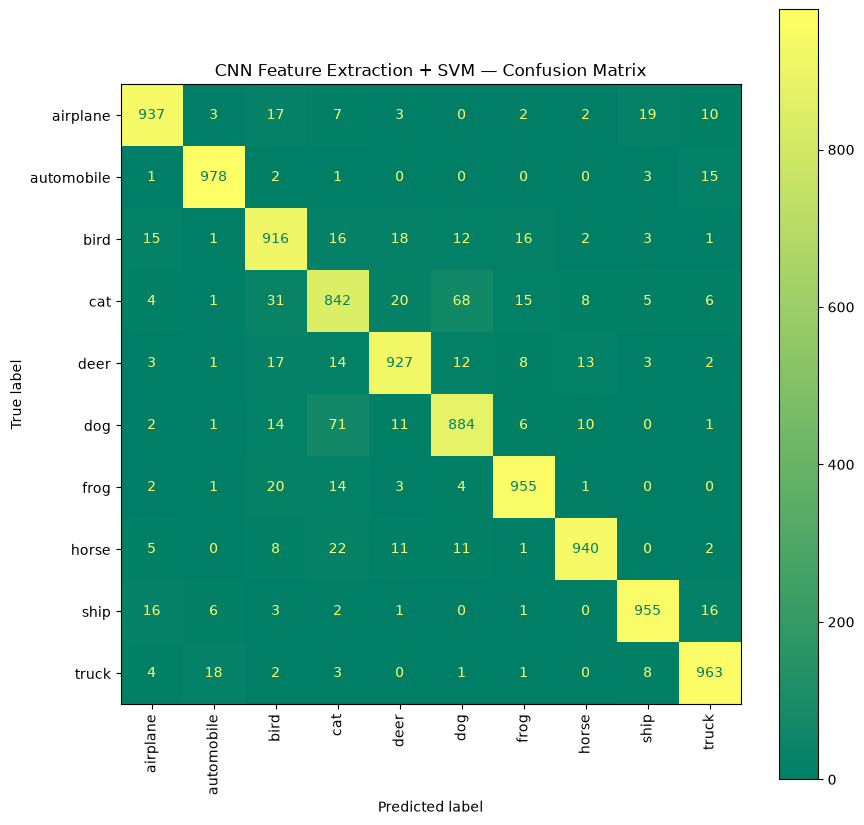

In [44]:
cm = confusion_matrix(
    y_test,
    svm_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp.plot(
    ax=ax,
    xticks_rotation="vertical",
    cmap="summer"
)

plt.title(
    "CNN Feature Extraction + SVM "
    "— Confusion Matrix"
)

plt.show()

## 11. Beberapa Hasil Prediksi

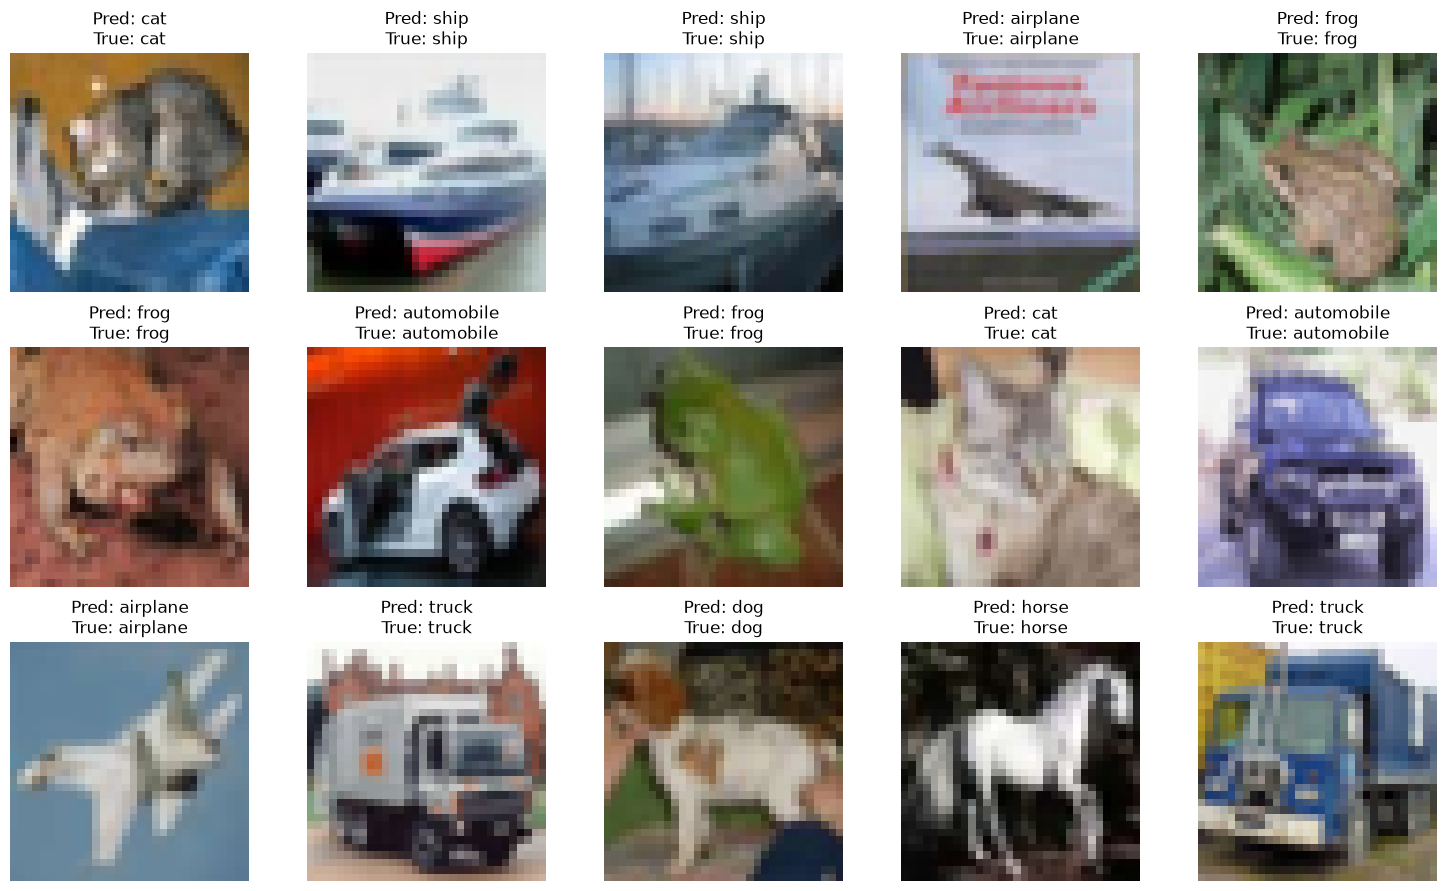

In [45]:
num_rows = 3
num_cols = 5
num_images = (
    num_rows * num_cols
)

plt.figure(figsize=(15, 9))

for i in range(num_images):
    plt.subplot(
        num_rows,
        num_cols,
        i + 1
    )

    plt.imshow(
        X_test[i]
    )

    predicted = int(
        svm_prediction[i]
    )

    actual = int(
        y_test[i]
    )

    plt.title(
        f"Pred: {labels[predicted]}\n"
        f"True: {labels[actual]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# RGB v2 official test complete

The reported scores use saved RGB v2 CNN and SVM artifacts. No model fitting or parameter selection occurs in this notebook.
